In [48]:
#Aim: to keep the notebook as clean as possible. 

In [49]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files
from datetime import datetime

%matplotlib inline

In [50]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [51]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file


In [52]:

fnames={}


case_abr = { # case abbreviations
    "SC" : "FACE_1PFT_r250210_Best_Cal",
    "SCnew" : "FACE_1PFT_r250421_reCal",
    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    "EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    "ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",
    "SCnV" : "FACE_1PFT_r250425_MCMCV",
#SD: FACE_1PFT_r2503121_SD_b4OLMTparms | it will replace the above

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly", # commenting for NUP
            "RD",
            "ECA",
            ]

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            # COnly
            fnames[f"{c_abr}_{s_abr}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            #fn = ['RD','ECA']
            for fn in ['RD','ECA']:
                fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}.nc"

In [53]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    #print (key, ":" , fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key])
    

In [54]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [55]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_91107/2440484563.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_91107/2440484563.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_91107/2440484563.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_91107/2440484563.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_91107/2440484563.py:43: UserWarn

In [56]:
case_abr

{'SC': 'FACE_1PFT_r250210_Best_Cal',
 'SCnew': 'FACE_1PFT_r250421_reCal',
 'SD': 'FACE_1PFT_r2503121_SD_b4OLMTparms',
 'EC': 'FACE_1PFT_r250314_NoLog_CalParams',
 'ED': 'FACE_1PFT_r2503121_ED_b4OLMTparms',
 'SCnV': 'FACE_1PFT_r250425_MCMCV'}

In [57]:
# make dictionary of plots
# ------------------------
data_plots = {}
data_plots_obs = {}

## Inputs

In [58]:
case_abr

{'SC': 'FACE_1PFT_r250210_Best_Cal',
 'SCnew': 'FACE_1PFT_r250421_reCal',
 'SD': 'FACE_1PFT_r2503121_SD_b4OLMTparms',
 'EC': 'FACE_1PFT_r250314_NoLog_CalParams',
 'ED': 'FACE_1PFT_r2503121_ED_b4OLMTparms',
 'SCnV': 'FACE_1PFT_r250425_MCMCV'}

In [59]:
# Inputs
# ======

case_plot = "SCnV" # 'SC', 'SD','EC', 'ED',"SCnew" 
var_obs= "Stand_Density"
data_plots[case_plot] = {}

var_names = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
        #"NPP_alloc",
        "Stand_Density",
       )
# plot obs? 
obs_plot = 1 # 0,1
plot_period = "start" # "start", "end"


dict_time_select = {}
dict_time_select ["ORNL"] = {}
dict_time_select ["DUKE"] = {}
dict_time_select ["ORNL"]["start"] = "1998-01-01"
dict_time_select ["ORNL"]["end"]   = "2008-07-01"

dict_time_select ["DUKE"]["start"] = "1996-07-01"
dict_time_select ["DUKE"]["end"]   = "2007-07-01"

## Obs stand density

In [60]:
path_demography_data = '/Users/ud4/Documents/FACEMDS/Demography_Data'
Duke_dbh_fname = f'{path_demography_data}/Duke/DUKE-FACE_BasalArea.csv'
ORNL_dbh_fname = f'{path_demography_data}/ORNL/ORNL-FACE_BasalArea_Norby.csv'

# reading the data
df_ORNL = pd.read_csv(ORNL_dbh_fname)
df_ORNL['dbh_cm'] = np.sqrt((4 * df_ORNL['BA']) / np.pi)


# reading the data
df_DUKE = pd.read_csv(Duke_dbh_fname)
df_DUKE['dbh_cm'] = np.sqrt((4 * df_DUKE['BA']) / np.pi)
# keeping only PITA species
df_DUKE = df_DUKE[df_DUKE['Species'] == 'PITA']

In [61]:
# Group rings by CO2 treatment
rings_by_co2 = df_DUKE.groupby('co2')['RING'].unique()
print(rings_by_co2)


co2
amb    [1, 5, 6, 8]
ele    [2, 3, 4, 7]
Name: RING, dtype: object


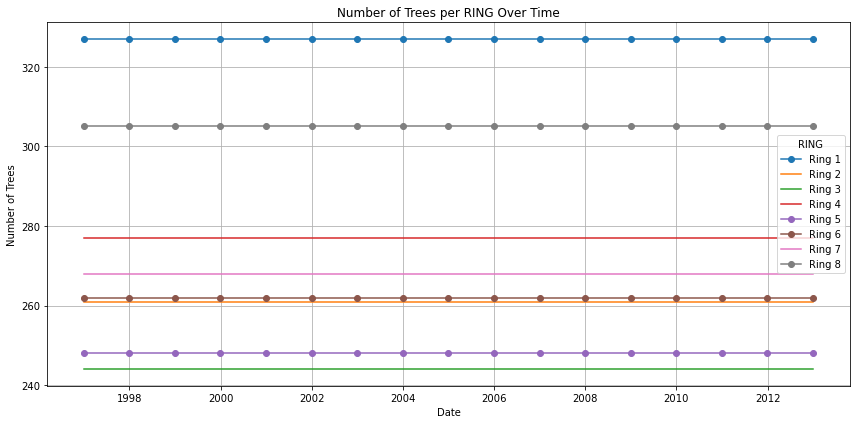

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data (if not already in a DataFrame)
# df = pd.read_csv('your_file.csv')  # or already loaded as 'df'
df = pd.read_csv(Duke_dbh_fname)

# Ensure 'ptime' is datetime
df['ptime'] = pd.to_datetime(df['ptime'])

# Group by actual date and RING, count number of trees
tree_counts = df.groupby(['ptime', 'RING']).size().unstack()

# Sort by date
tree_counts = tree_counts.sort_index()

# Plot
plt.figure(figsize=(12, 6))
for ring in tree_counts.columns:
    if ring in (1,5,6,8):
        plt.plot(tree_counts.index, tree_counts[ring], label=f'Ring {ring}', marker = 'o')
    else:
        plt.plot(tree_counts.index, tree_counts[ring], label=f'Ring {ring}')

plt.title('Number of Trees per RING Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Trees')
plt.legend(title='RING')
plt.grid(True)
plt.tight_layout()
plt.show()


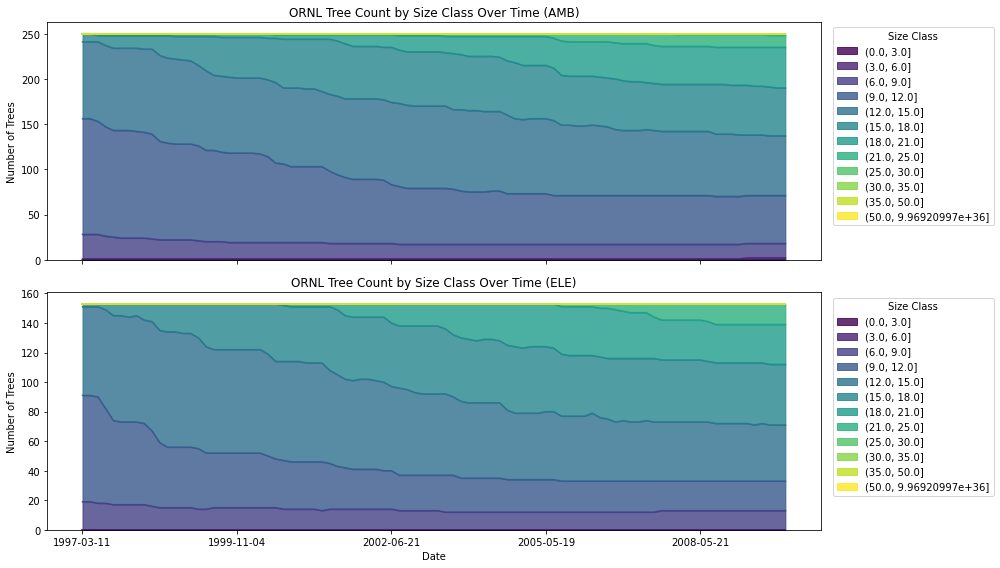

In [63]:


df = pd.read_csv(ORNL_dbh_fname)
df['dbh_cm'] = np.sqrt((4 * df['BA']) / np.pi)

# Total area per treatment in m²
plot_areas_m2 = {
    'amb': 314 * 3,   # 942 m²
    'ele': 314 * 2    # 628 m²
}



# Define DBH size class bins
bins = np.array([
    0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0,
    25.0, 30.0, 35.0, 50.0, 9.96920997e+36
])

# Filter only alive trees
alive_df = df[df['die'] == False].copy()

# Assign DBH size class bins
alive_df['size_class'] = pd.cut(alive_df['dbh_cm'], bins=bins)

# Group by co2 treatment, date, and size class → count number of trees
count_df = alive_df.groupby(['co2', 'ptime', 'size_class']).size()

# Reshape the data for plotting
count_df = count_df.unstack(level='size_class', fill_value=0)

# Plot for each CO2 treatment
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, co2_type in enumerate(['amb', 'ele']):
    if co2_type in count_df.index.get_level_values(0):
        subset = count_df.loc[co2_type]

        subset.plot.area(ax=axes[i], stacked=True, cmap='viridis', alpha=0.8)
        axes[i].set_title(f'ORNL Tree Count by Size Class Over Time ({co2_type.upper()})')
        axes[i].set_ylabel('Number of Trees')
        axes[i].legend(title='Size Class', bbox_to_anchor=(1.01, 1), loc='upper left')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


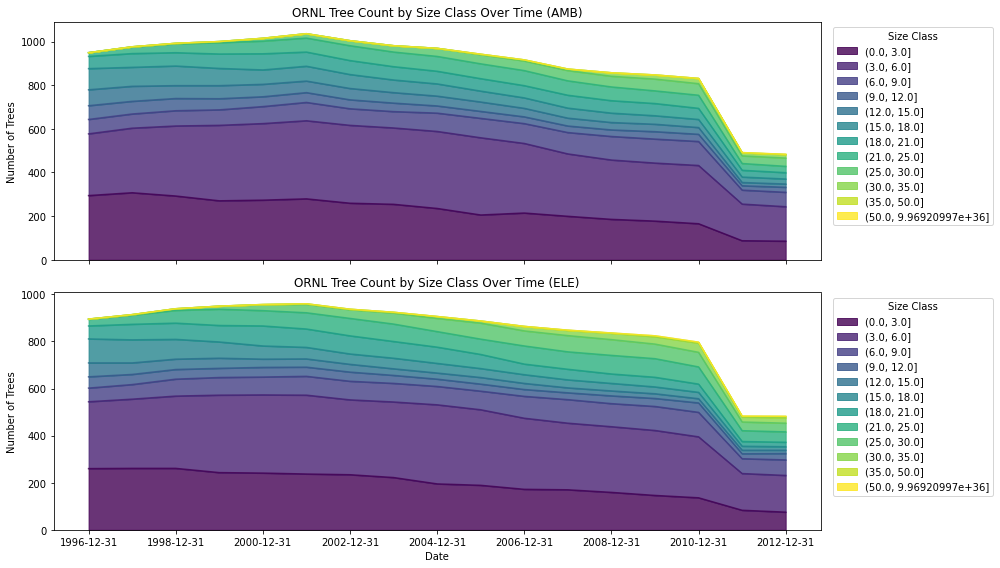

In [64]:


df = pd.read_csv(Duke_dbh_fname)
df['dbh_cm'] = np.sqrt((4 * df['BA']) / np.pi)

# Total area per treatment in m²
plot_areas_m2 = {
    'amb': 490.625 * 4,   # 1962.5 m²
    'ele': 490.625 * 4    # 1962.5 m²
}



# Define DBH size class bins
bins = np.array([
    0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0,
    25.0, 30.0, 35.0, 50.0, 9.96920997e+36
])

# Filter only alive trees
alive_df = df[df['die'] == False].copy()

# Assign DBH size class bins
alive_df['size_class'] = pd.cut(alive_df['dbh_cm'], bins=bins)

# Group by co2 treatment, date, and size class → count number of trees
count_df = alive_df.groupby(['co2', 'ptime', 'size_class']).size()

# Reshape the data for plotting
count_df = count_df.unstack(level='size_class', fill_value=0)

# Plot for each CO2 treatment
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, co2_type in enumerate(['amb', 'ele']):
    if co2_type in count_df.index.get_level_values(0):
        subset = count_df.loc[co2_type]

        subset.plot.area(ax=axes[i], stacked=True, cmap='viridis', alpha=0.8)
        axes[i].set_title(f'ORNL Tree Count by Size Class Over Time ({co2_type.upper()})')
        axes[i].set_ylabel('Number of Trees')
        axes[i].legend(title='Size Class', bbox_to_anchor=(1.01, 1), loc='upper left')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


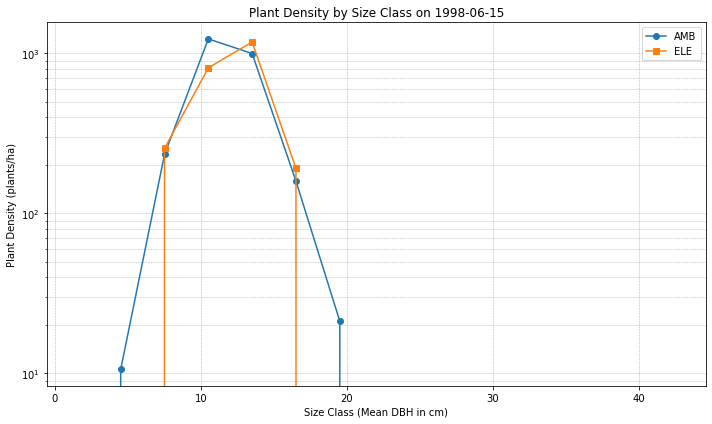

In [65]:
# ORNL

df = pd.read_csv(ORNL_dbh_fname)
df['dbh_cm'] = np.sqrt((4 * df['BA']) / np.pi)

# --- Step 1: Clean data ---
df_clean = df.copy()

# Ensure ptime is datetime
df_clean['ptime'] = pd.to_datetime(df_clean['ptime'], errors='coerce')

# Ensure dbh_cm is numeric
df_clean['dbh_cm'] = pd.to_numeric(df_clean['dbh_cm'], errors='coerce')

# Filter for living trees
df_alive = df_clean[df_clean['die'] == False].dropna(subset=['dbh_cm', 'ptime'])

# DBH size class bins
bins = np.array([0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 25.0, 30.0, 35.0, 50.0, np.inf])
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
bin_means = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# Create size_class column
df_alive['size_class'] = pd.cut(df_alive['dbh_cm'], bins=bins, labels=bin_labels, right=False)

# Drop rows where size_class is NaN (e.g., dbh_cm not in any bin)
df_alive = df_alive.dropna(subset=['size_class'])

# --- Step 3: Count number of trees per time, co2 treatment, and size class ---
grouped = df_alive.groupby(['co2', 'ptime', 'size_class']).size()

# Reshape to wide format (size_class columns)
grouped = grouped.unstack(fill_value=0)


# Area per treatment (m2)
plot_areas_m2 = {'amb': 314 * 3, 'ele': 314 * 2}  # 3 AMB plots, 2 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime('1998-07-01')
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_amb = counts_amb * 10_000 / plot_areas_m2['amb']
density_ele = counts_ele * 10_000 / plot_areas_m2['ele']

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.semilogy(bin_means, density_amb.values, marker='o', label='AMB')
plt.semilogy(bin_means, density_ele.values, marker='s', label='ELE')
plt.xlabel("Size Class (Mean DBH in cm)")
plt.ylabel("Plant Density (plants/ha)")
plt.title(f"Plant Density by Size Class on {nearest_date.date()}")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Normalizing the bin spaces (ORNL)

In [66]:
# ORNL

diff_bins = np.diff(bins)
print (diff_bins)
print ("replacing the last one with a value of 50")
diff_bins[-1] = 50
print("diff bin size", diff_bins.size)

print ("since bins have one extra element, deleting it")
bins = bins[:-1]

print ("Now we will be ploting nplants/cm / area")

[ 3.  3.  3.  3.  3.  3.  3.  4.  5.  5. 15. inf]
replacing the last one with a value of 50
diff bin size 12
since bins have one extra element, deleting it
Now we will be ploting nplants/cm / area


fig start COnly
fig end COnly ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_COnly.pdf


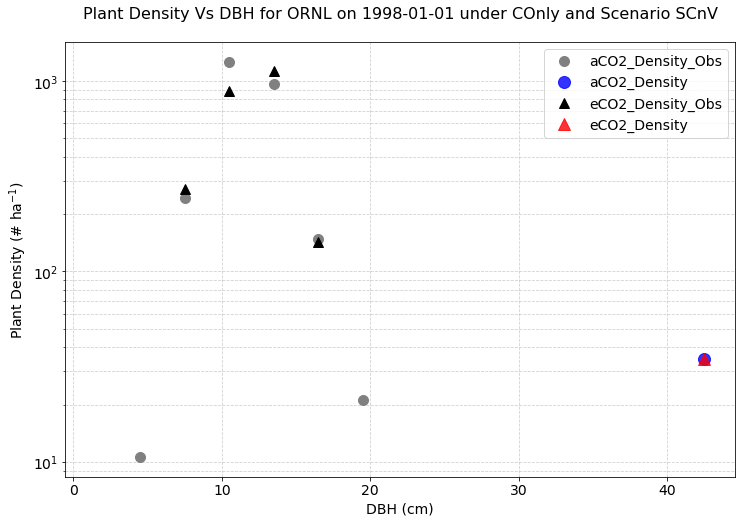

fig start RD
fig end RD ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_RD.pdf


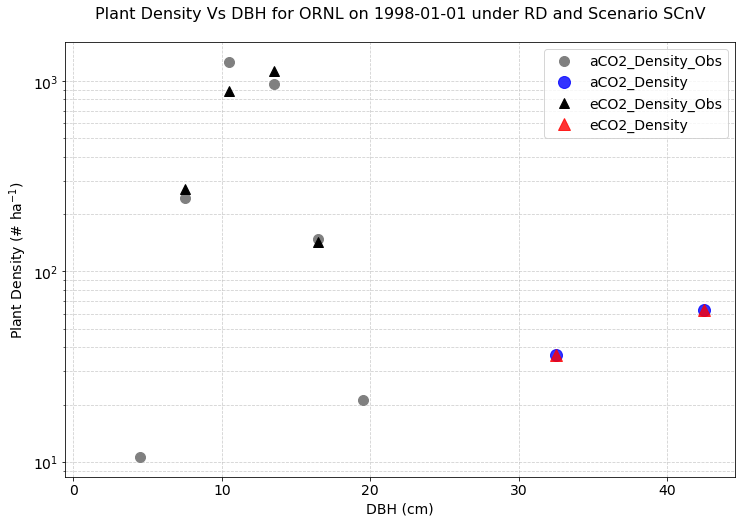

fig start ECA
fig end ECA ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_ECA.pdf


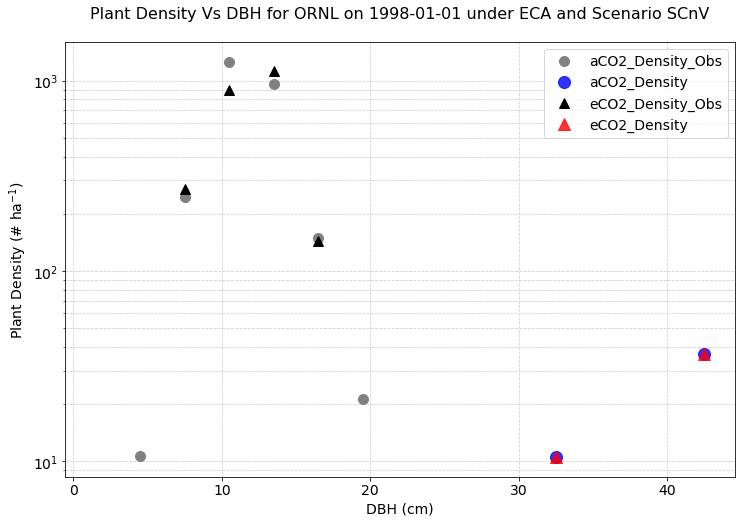

In [67]:

select_site = "US-ORN"
site = "ORNL"

# Area per treatment (m2)
plot_areas_m2 = {'amb': 314 * 3, 'ele': 314 * 2}  # 3 AMB plots, 2 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime(dict_time_select[site][plot_period])
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_obs_tmp = {}
density_obs_tmp['AMB'] = counts_amb * 10_000 / plot_areas_m2['amb']
density_obs_tmp['ELE'] = counts_ele * 10_000 / plot_areas_m2['ele']


data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "gray"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = "^"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "black"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    plt.plot(bin_means, density_obs_tmp[co2_case].values, 
                             color=color_obs, marker=marker_line, 
                             linestyle='',markersize=10,
                             label=f'{tmp_case}_Density_Obs')
                    #plt.semilogy(bin_means, density_ele.values, marker='s', label='ELE')

                    ran_twice +=1
                    # DBH size class bin
                    
                if var == "NUP":
                    tmp_var = ( 
                        ds[key]['FATES_NH4UPTAKE'] +
                        ds[key]['FATES_NH4UPTAKE'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "NUP", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]

                if var == "Stand_Density":
                    plant_density = ds[key]["FATES_NPLANT_SZ"]
                    time_value =  plant_density.sel(
                        time=dict_time_select[key.split('_')[1]][f"{plot_period}"]).time
                    # selecting the PD for a specific time
                    plant_density_time = ds[key]["FATES_NPLANT_SZ"].sel(
                        time = time_value)
                    
                    # date
                    string_date = time_value.dt.strftime('%Y-%m-%d').values
                    
                    # Extract data
                    nplant = plant_density_time.squeeze()*10000  # n m-2 to n ha-2
                    size_classes = ds[key]["fates_levscls"].values  # Get fates_levscls values
                    
                    valid = np.isfinite(nplant.values.flatten()) #& (nplant.values.flatten() > 0)
                    valid[-1] = False # ignore the last
                    nplant_valid = nplant.values.flatten()[valid]
                    size_classes[-1] = np.inf
                    size_classes_valid = size_classes[valid]
                    # bins
                    bin_labels_mod = [f"{size_classes[i]}-{size_classes[i+1]}" for i in range(len(size_classes)-1)]
                    bin_means_mod = [(size_classes[i] + size_classes[i+1]) / 2 for i in range(len(size_classes)-1)]
                    plt.plot(bin_means_mod, nplant_valid,
                            #'o-', 
                            #label="Density vs Basal Area"
                            label = tmp_case + '_'+ "Density", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2,
                            linestyle='',
                            markersize=12)
                    plt.yscale("log")

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"Plant Density (# ha$^{-1}$)", fontsize=14)
                plt.xlabel(r"DBH (cm)", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                # Add ticks
                #plt.ylim(30,1500)
                #plt.xlim(9,20)
                plt.grid(True, which="both", linestyle="--", alpha=0.6)
                plt.title(f"Plant Density Vs DBH for {site} on {string_date[0]} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

### Normalized plots (ORNL)

fig start COnly
fig end COnly ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_COnly.pdf


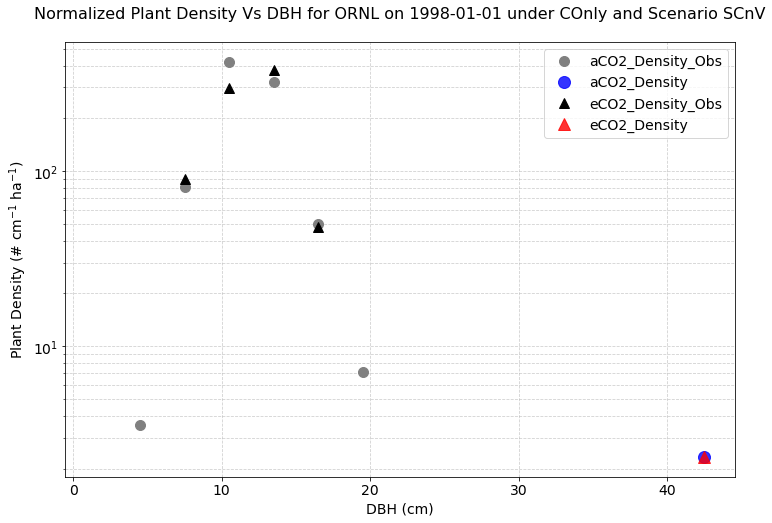

fig start RD
fig end RD ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_RD.pdf


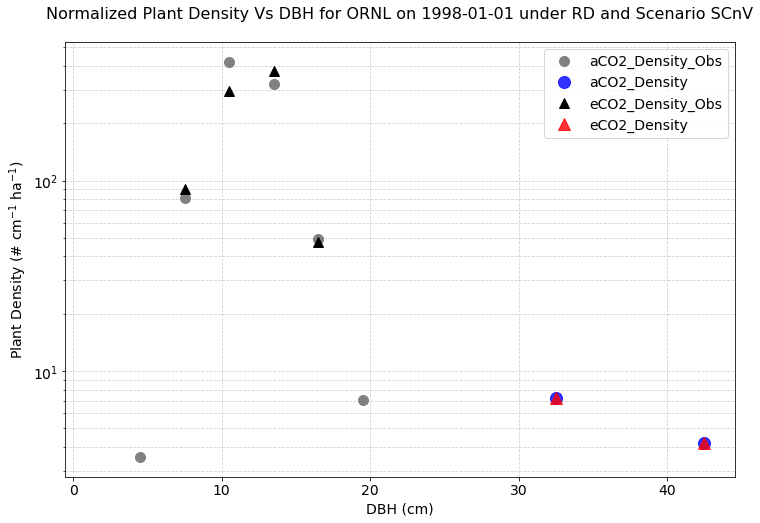

fig start ECA
fig end ECA ORNL
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1998_sce_SCnV_ORNL_ECA.pdf


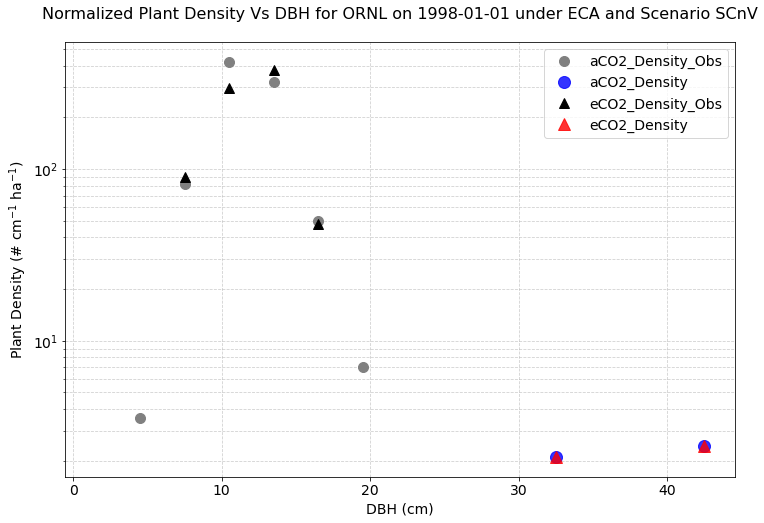

In [68]:
# Normalized

select_site = "US-ORN"
site = "ORNL"

# Area per treatment (m2)
plot_areas_m2 = {'amb': 314 * 3, 'ele': 314 * 2}  # 3 AMB plots, 2 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime(dict_time_select[site][plot_period])
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_obs_tmp = {}
density_obs_tmp['AMB'] = counts_amb * 10_000 / plot_areas_m2['amb']
density_obs_tmp['ELE'] = counts_ele * 10_000 / plot_areas_m2['ele']


data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "gray"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = "^"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "black"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    # Normalized Obs density per CM DBH
                    norm_density = density_obs_tmp[co2_case].values/diff_bins
                    plt.plot(bin_means, norm_density, 
                             color=color_obs, marker=marker_line, 
                             linestyle='',markersize=10,
                             label=f'{tmp_case}_Density_Obs')
                    #plt.semilogy(bin_means, density_ele.values, marker='s', label='ELE')

                    ran_twice +=1
                    # DBH size class bin
                    
                if var == "NUP":
                    tmp_var = ( 
                        ds[key]['FATES_NH4UPTAKE'] +
                        ds[key]['FATES_NH4UPTAKE'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "NUP", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]

                if var == "Stand_Density":
                    plant_density = ds[key]["FATES_NPLANT_SZ"]
                    time_value =  plant_density.sel(
                        time=dict_time_select[key.split('_')[1]][f"{plot_period}"]).time
                    # selecting the PD for a specific time
                    plant_density_time = ds[key]["FATES_NPLANT_SZ"].sel(
                        time = time_value)
                    
                    # date
                    string_date = time_value.dt.strftime('%Y-%m-%d').values
                    
                    # Extract data
                    nplant = plant_density_time.squeeze()*10000  # n m-2 to n ha-2
                    size_classes = ds[key]["fates_levscls"].values  # Get fates_levscls values
                    
                    valid = np.isfinite(nplant.values.flatten()) #& (nplant.values.flatten() > 0)
                    valid[-1] = False # ignore the last
                    nplant_valid = nplant.values.flatten()[valid]
                    size_classes[-1] = np.inf
                    size_classes_valid = size_classes[valid]
                    # bins
                    bin_labels_mod = [f"{size_classes[i]}-{size_classes[i+1]}" for i in range(len(size_classes)-1)]
                    bin_means_mod = [(size_classes[i] + size_classes[i+1]) / 2 for i in range(len(size_classes)-1)]
                    # Normalized Obs density per CM DBH
                    norm_density_mod = nplant_valid/diff_bins
                    
                    plt.plot(bin_means_mod, norm_density_mod,
                            #'o-', 
                            #label="Density vs Basal Area"
                            label = tmp_case + '_'+ "Density", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2,
                            linestyle='',
                            markersize=12)
                    plt.yscale("log")

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"Plant Density (# cm$^{-1}$ ha$^{-1}$)", fontsize=14)
                plt.xlabel(r"DBH (cm)", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                # Add ticks
                #plt.ylim(30,1500)
                #plt.xlim(9,20)
                plt.grid(True, which="both", linestyle="--", alpha=0.6)
                plt.title(f"Normalized Plant Density Vs DBH for {site} on {string_date[0]} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/Norm{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/Norm{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

## DUKE

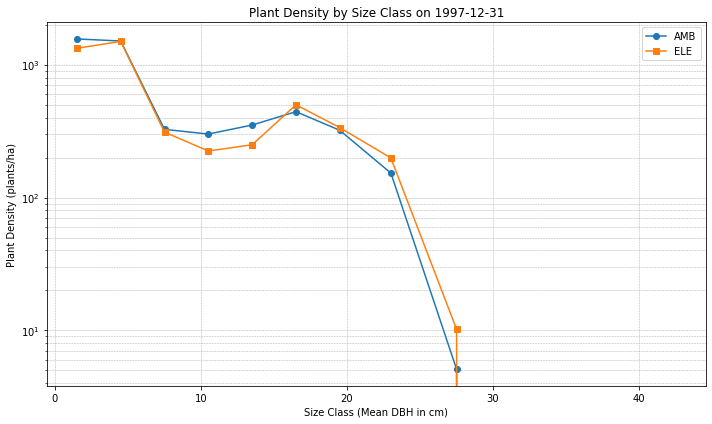

In [69]:
# DUKE

df = pd.read_csv(Duke_dbh_fname)
df['dbh_cm'] = np.sqrt((4 * df['BA']) / np.pi)

# --- Step 1: Clean data ---
df_clean = df.copy()

# Ensure ptime is datetime
df_clean['ptime'] = pd.to_datetime(df_clean['ptime'], errors='coerce')

# Ensure dbh_cm is numeric
df_clean['dbh_cm'] = pd.to_numeric(df_clean['dbh_cm'], errors='coerce')

# Filter for living trees
df_alive = df_clean[df_clean['die'] == False].dropna(subset=['dbh_cm', 'ptime'])

# DBH size class bins
bins = np.array([0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 25.0, 30.0, 35.0, 50.0, np.inf])
bin_labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
bin_means = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# Create size_class column
df_alive['size_class'] = pd.cut(df_alive['dbh_cm'], bins=bins, labels=bin_labels, right=False)

# Drop rows where size_class is NaN (e.g., dbh_cm not in any bin)
df_alive = df_alive.dropna(subset=['size_class'])

# --- Step 3: Count number of trees per time, co2 treatment, and size class ---
grouped = df_alive.groupby(['co2', 'ptime', 'size_class']).size()

# Reshape to wide format (size_class columns)
grouped = grouped.unstack(fill_value=0)


# Area per treatment (m2)
plot_areas_m2 = {'amb': 490.625 * 4, 'ele': 490.625 * 4}  # 4 AMB plots, 4 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime('1998-07-01')
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_amb = counts_amb * 10_000 / plot_areas_m2['amb']
density_ele = counts_ele * 10_000 / plot_areas_m2['ele']

# Step 3: Plot
plt.figure(figsize=(10, 6))
plt.semilogy(bin_means, density_amb.values, marker='o', label='AMB')
plt.semilogy(bin_means, density_ele.values, marker='s', label='ELE')
plt.xlabel("Size Class (Mean DBH in cm)")
plt.ylabel("Plant Density (plants/ha)")
plt.title(f"Plant Density by Size Class on {nearest_date.date()}")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Normalized Bins (DUKE)

In [70]:
# DUKE

diff_bins = np.diff(bins)
print (diff_bins)
print ("replacing the last one with a value of 50")
diff_bins[-1] = 50
print("diff bin size", diff_bins.size)

print ("since bins have one extra element, deleting it")
bins = bins[:-1]

print ("Now we will be ploting nplants/cm / area")

[ 3.  3.  3.  3.  3.  3.  3.  4.  5.  5. 15. inf]
replacing the last one with a value of 50
diff bin size 12
since bins have one extra element, deleting it
Now we will be ploting nplants/cm / area


fig start COnly
fig end COnly DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_COnly.pdf


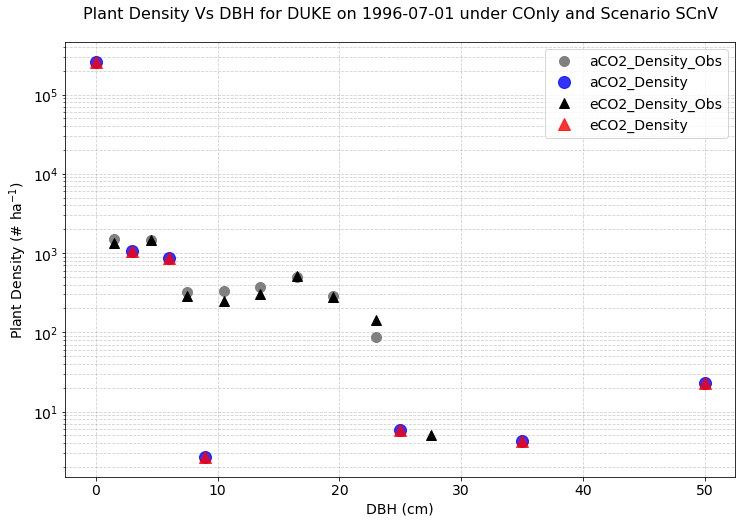

fig start RD
fig end RD DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_RD.pdf


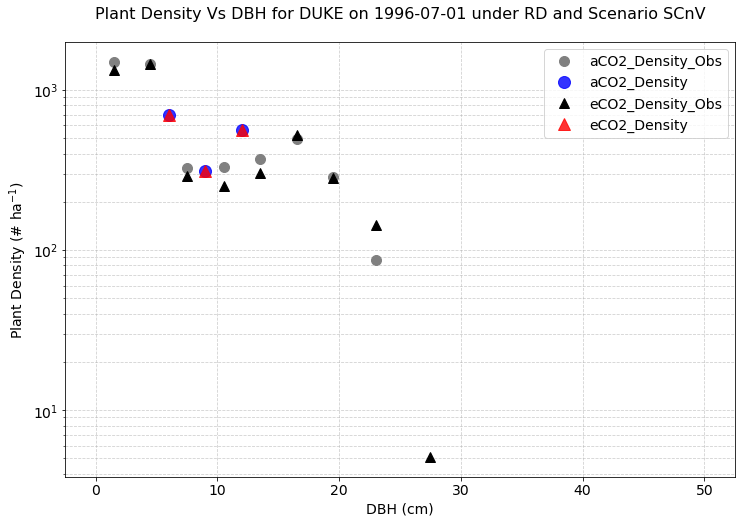

fig start ECA
fig end ECA DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_ECA.pdf


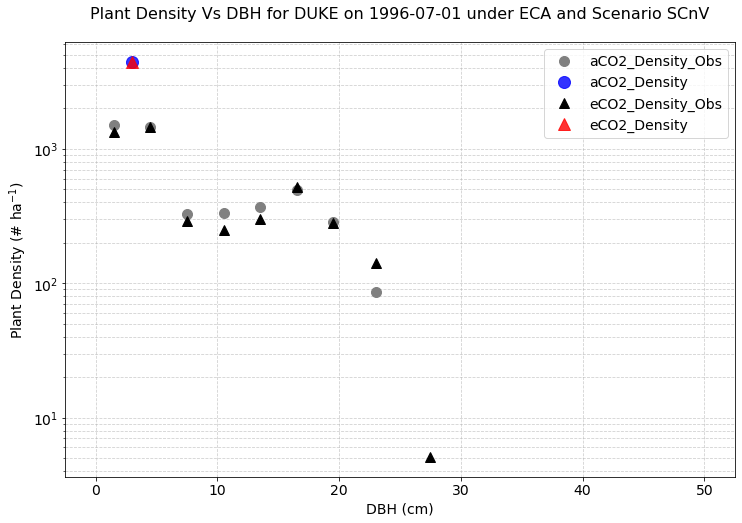

In [71]:
select_site = "US-DUK"
site = "DUKE"

data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

# Area per treatment (m2)
plot_areas_m2 = {'amb': 490.625 * 4, 'ele': 490.625 * 4}  # 4 AMB plots, 4 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime(dict_time_select[site][plot_period])
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_obs_tmp = {}
density_obs_tmp['AMB'] = counts_amb * 10_000 / plot_areas_m2['amb']
density_obs_tmp['ELE'] = counts_ele * 10_000 / plot_areas_m2['ele']


li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1996-01-01", "2007-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "gray"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = "^"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "black"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    plt.plot(bin_means, density_obs_tmp[co2_case].values, 
                             color=color_obs, marker=marker_line, 
                             linestyle='',markersize=10,
                             label=f'{tmp_case}_Density_Obs')
                    ran_twice +=1
                    
                if var == "NUP":
                    tmp_var = ( 
                        ds[key]['FATES_NH4UPTAKE'] +
                        ds[key]['FATES_NH4UPTAKE'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "NUP", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]

                if var == "Stand_Density":
                    plant_density = ds[key]["FATES_NPLANT_SZ"]
                    time_value =  plant_density.sel(
                        time=dict_time_select[key.split('_')[1]][f"{plot_period}"]).time
                    # selecting the PD for a specific time
                    plant_density_time = ds[key]["FATES_NPLANT_SZ"].sel(
                        time = time_value)
                    
                    # date
                    string_date = time_value.dt.strftime('%Y-%m-%d').values
                    
                    # Extract data
                    nplant = plant_density_time.squeeze()*10000  # n m-2 to n ha-2
                    size_classes = ds[key]["fates_levscls"].values  # Get fates_levscls values
                    
                    valid = np.isfinite(nplant.values.flatten()) #& (nplant.values.flatten() > 0)
                    valid[-1] = False # ignore the last
                    nplant_valid = nplant.values.flatten()[valid]
                    size_classes_valid = size_classes[valid]
                    
                    plt.plot(size_classes_valid, nplant_valid,
                            #'o-', 
                            #label="Density vs Basal Area"
                            label = tmp_case + '_'+ "Density", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2,
                            linestyle='',
                            markersize=12)
                    plt.yscale("log")

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"Plant Density (# ha$^{-1}$)", fontsize=14)
                plt.xlabel(r"DBH (cm)", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                # Add ticks
                #plt.ylim(30,1500)
                #plt.xlim(9,20)
                plt.grid(True, which="both", linestyle="--", alpha=0.6)
                plt.title(f"Plant Density Vs DBH for {site} on {string_date[0]} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()

fig start COnly
fig end COnly DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_COnly.pdf


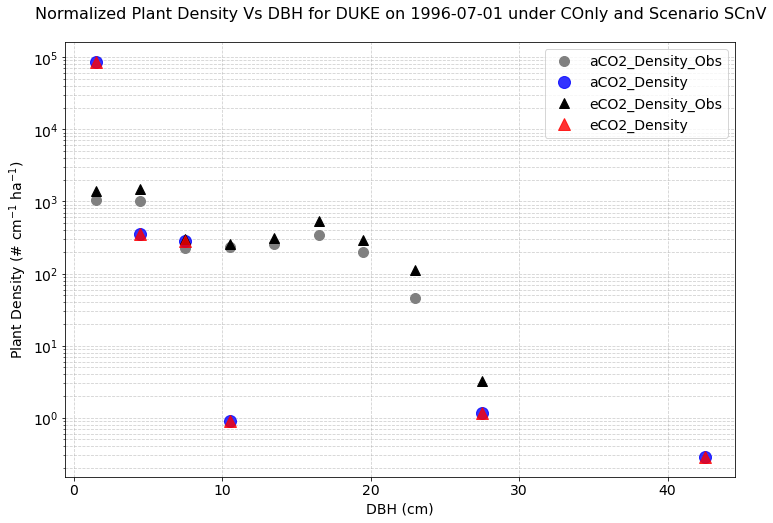

fig start RD
fig end RD DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_RD.pdf


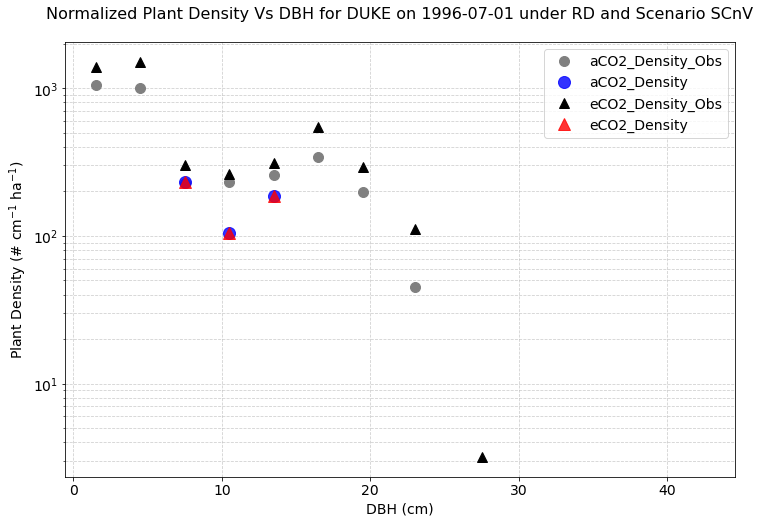

fig start ECA
fig end ECA DUKE
/Users/ud4/Documents/FACEMDS/Figures_Paper/Stand_Density_1996_sce_SCnV_DUKE_ECA.pdf


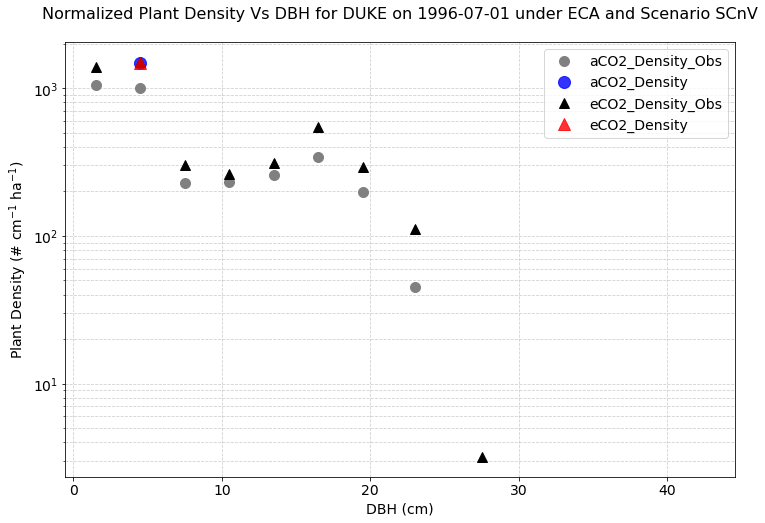

In [72]:
# Normalized

select_site = "US-DUK"
site = "DUKE"

# Area per treatment (m2)
plot_areas_m2 = {'amb': 314 * 3, 'ele': 314 * 2}  # 3 AMB plots, 2 ELE plots

# Step 1: Find the row with date nearest to 1998-07-01
target_date = pd.to_datetime(dict_time_select[site][plot_period])
grouped_reset = grouped.reset_index()
grouped_reset['ptime'] = pd.to_datetime(grouped_reset['ptime'])

# Get nearest date
nearest_idx = (grouped_reset['ptime'] - target_date).abs().idxmin()
nearest_date = grouped_reset.loc[nearest_idx, 'ptime']

# Step 2: Extract data for both AMB and ELE
counts_amb = grouped.loc[('amb', nearest_date)]
counts_ele = grouped.loc[('ele', nearest_date)]

# Convert to plants per hectare
density_obs_tmp = {}
density_obs_tmp['AMB'] = counts_amb * 10_000 / plot_areas_m2['amb']
density_obs_tmp['ELE'] = counts_ele * 10_000 / plot_areas_m2['ele']


data_plots[case_plot][site] = {}
data_plots_obs[site] = {}

li = 0 # for legend index
for sim_case in sim_cases:
    data_plots[case_plot][site][sim_case] = {}
    ran_twice = 0  # Flag to track execution
    plt.figure(figsize=(12,8))
    print ("fig start",sim_case)
    for var in var_names:
        data_plots[case_plot][site][sim_case][var] = {}
        data_plots_obs[site][var_obs] = {}
        for idx, key in enumerate(ds.keys()):
            if sim_case not in key:
                continue
            if (f"{site}" in key) and (f"{case_plot}_" in key): 
                time = pd.date_range("1998-01-01", "2008-12-31", freq="A")  # Monthly data
                if "aCO2" in key:
                    color_line = "b"
                    marker_line = "o"
                    co2_case = "AMB"
                    tmp_case = "aCO2"
                    color_obs = "gray"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if "eCO2" in key:
                    color_line = "r"
                    marker_line = "^"
                    co2_case = "ELE"
                    tmp_case = "eCO2"
                    color_obs = "black"
                    data_plots_obs[site][var_obs][tmp_case] = {}
                if (obs_plot ==1) and (ran_twice<2):
                    Mean_DF = dict_obs_ax[site][co2_case]
                    Standard_error_DF = dict_obs_ase[site][co2_case]
                    # Extracting the relevant columns
                    # Normalized Obs density per CM DBH
                    norm_density = density_obs_tmp[co2_case].values/diff_bins
                    plt.plot(bin_means, norm_density, 
                             color=color_obs, marker=marker_line, 
                             linestyle='',markersize=10,
                             label=f'{tmp_case}_Density_Obs')
                    #plt.semilogy(bin_means, density_ele.values, marker='s', label='ELE')

                    ran_twice +=1
                    # DBH size class bin
                    
                if var == "NUP":
                    tmp_var = ( 
                        ds[key]['FATES_NH4UPTAKE'] +
                        ds[key]['FATES_NH4UPTAKE'] 
                    )*24*3600*365*1000   
                    plt.plot(time, tmp_var.groupby("time.year").mean(), 
                             #label = tmp_legend_name(key).split('_')[-1]+'_'+var, 
                             label = tmp_case + '_'+ "NUP", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2)
                    data_plots[case_plot][site][sim_case][var][tmp_case] = tmp_var.groupby("time.year").mean().values[:, 0]

                if var == "Stand_Density":
                    plant_density = ds[key]["FATES_NPLANT_SZ"]
                    time_value =  plant_density.sel(
                        time=dict_time_select[key.split('_')[1]][f"{plot_period}"]).time
                    # selecting the PD for a specific time
                    plant_density_time = ds[key]["FATES_NPLANT_SZ"].sel(
                        time = time_value)
                    
                    # date
                    string_date = time_value.dt.strftime('%Y-%m-%d').values
                    
                    # Extract data
                    nplant = plant_density_time.squeeze()*10000  # n m-2 to n ha-2
                    size_classes = ds[key]["fates_levscls"].values  # Get fates_levscls values
                    
                    valid = np.isfinite(nplant.values.flatten()) #& (nplant.values.flatten() > 0)
                    valid[-1] = False # ignore the last
                    nplant_valid = nplant.values.flatten()[valid]
                    size_classes[-1] = np.inf
                    size_classes_valid = size_classes[valid]
                    # bins
                    bin_labels_mod = [f"{size_classes[i]}-{size_classes[i+1]}" for i in range(len(size_classes)-1)]
                    bin_means_mod = [(size_classes[i] + size_classes[i+1]) / 2 for i in range(len(size_classes)-1)]
                    # Normalized Obs density per CM DBH
                    norm_density_mod = nplant_valid/diff_bins
                    
                    plt.plot(bin_means_mod, norm_density_mod,
                            #'o-', 
                            #label="Density vs Basal Area"
                            label = tmp_case + '_'+ "Density", 
                             color = color_line,
                             marker = marker_line,
                             alpha=.8, linewidth=2,
                            linestyle='',
                            markersize=12)
                    plt.yscale("log")

                if False:
                    print (ds[key][var].long_name )
                plt.axhline(y = 0, color = 'k',lw=2, alpha=.02)
                plt.grid(True, linestyle="--", alpha=0.7)  # Dashed grid lines with better visibility
                plt.legend(fontsize=14,loc="upper right")
                plt.ylabel(r"Plant Density (# cm$^{-1}$ ha$^{-1}$)", fontsize=14)
                plt.xlabel(r"DBH (cm)", fontsize=14)
                plt.xticks(fontsize=14)  # Increase x-axis tick font size
                plt.yticks(fontsize=14)  # Increase y-axis tick font size
                # Add ticks
                #plt.ylim(30,1500)
                #plt.xlim(9,20)
                plt.grid(True, which="both", linestyle="--", alpha=0.6)
                plt.title(f"Normalized Plant Density Vs DBH for {site} on {string_date[0]} under {sim_case} and Scenario {case_plot}\n",fontsize=16)
                #li+=1 # for legend index updating for a site
    print ("fig end",sim_case,site)
    print (f"{path_save_results}/{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf")
    plt.savefig(f"{path_save_results}/Norm{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(f"{path_save_results}/Norm{var_obs}_{string_date[0].split('-')[0]}_sce_{case_plot}_{site}_{sim_case}.png", format="png", dpi =200, bbox_inches="tight")
    plt.show()
    plt.close()